# DEEP NEURAL NETWORKS - ASSIGNMENT 2: CNN FOR IMAGE CLASSIFICATION

## Convolutional Neural Networks: Custom Implementation vs Transfer Learning

STUDENT INFORMATION (REQUIRED - DO NOT DELETE)

BITS ID: 2025AB05088

Name: P L V S ADITHYA

Email: 2025ab05088@wilp.bits-pilani.ac.in

Date: 06-02-2026

In [1]:
# Import Required Libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
import torchvision
from torchvision import datasets, models, transforms
from torch.cuda.amp import autocast, GradScaler

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
import time
import json
import os
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

if torch.cuda.is_available():
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
    device = torch.device('cuda')
else:
    print("WARNING: CUDA not available, using CPU")
    device = torch.device('cpu')

print(f"\nUsing device: {device}")

CUDA Version: 12.1
GPU Device: NVIDIA GeForce RTX 4070 Laptop GPU
GPU Memory: 8.00 GB

Using device: cuda


In [2]:
# Deep learning frameworks (choose Keras or PyTorch)
# For image processing
from PIL import Image


### 1.1 Dataset Selection and Loading


In [3]:
# REQUIRED: Fill in these metadata fields
dataset_name = "Chest X-Ray Images (Pneumonia)"
dataset_source = "Kaggle"
n_samples = 5856  # Total number of images
n_classes = 2  # Number of classes
samples_per_class = "min: 1583, max: 4273, avg: 2928"
image_shape = [224, 224, 3]  # [height, width, channels]
problem_type = "classification"

In [4]:
# Primary metric selection
primary_metric = "Recall"
metric_justification = """
Recall is chosen as the primary metric because in medical diagnosis (pneumonia detection),
minimizing false negatives is critical. Missing a pneumonia case (false negative) could have
severe health consequences, while false positives can be verified through additional tests.
"""

In [5]:
print("DATASET INFORMATION")
print(f"Dataset: {dataset_name}")
print(f"Source: {dataset_source}")
print(f"Total Samples: {n_samples}")
print(f"Number of Classes: {n_classes}")
print(f"Samples per Class: {samples_per_class}")
print(f"Image Shape: {image_shape}")
print(f"Primary Metric: {primary_metric}")
print(f"Metric Justification: {metric_justification}")

DATASET INFORMATION
Dataset: Chest X-Ray Images (Pneumonia)
Source: Kaggle
Total Samples: 5856
Number of Classes: 2
Samples per Class: min: 1583, max: 4273, avg: 2928
Image Shape: [224, 224, 3]
Primary Metric: Recall
Metric Justification: 
Recall is chosen as the primary metric because in medical diagnosis (pneumonia detection),
minimizing false negatives is critical. Missing a pneumonia case (false negative) could have
severe health consequences, while false positives can be verified through additional tests.



In [6]:
# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True

print('Random seeds set for reproducibility')

Random seeds set for reproducibility


In [7]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet stats
                        std=[0.229, 0.224, 0.225])
])

# No augmentation for test
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

print('Transforms defined:')
print(f'Training: {len(train_transforms.transforms)} operations')
print(f'Testing: {len(test_transforms.transforms)} operations')

Transforms defined:
Training: 7 operations
Testing: 3 operations


In [8]:
# Dataset paths
base_dir = 'chest_xray'
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

# Load datasets
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=test_transforms)

# Dataset info
n_train = len(train_dataset)
n_test = len(test_dataset)
n_classes = len(train_dataset.classes)
class_names = train_dataset.classes

print(f'Dataset: Chest X-Ray Images (Pneumonia)')
print(f'Classes: {class_names}')
print(f'Training samples: {n_train}')
print(f'Test samples: {n_test}')
print(f'Total samples: {n_train + n_test}')
print(f'Train/Test ratio: {n_train/(n_train+n_test)*100:.1f}% / {n_test/(n_train+n_test)*100:.1f}%')

Dataset: Chest X-Ray Images (Pneumonia)
Classes: ['NORMAL', 'PNEUMONIA']
Training samples: 5270
Test samples: 586
Total samples: 5856
Train/Test ratio: 90.0% / 10.0%


In [9]:
# Calculate class distribution
train_labels = [label for _, label in train_dataset]
class_counts = np.bincount(train_labels)

print('\nClass Distribution (Training):')
for i, (class_name, count) in enumerate(zip(class_names, class_counts)):
    print(f'  {class_name}: {count} samples ({count/n_train*100:.1f}%)')

imbalance_ratio = max(class_counts) / min(class_counts)
print(f'\nClass Imbalance Ratio: {imbalance_ratio:.2f}:1')


Class Distribution (Training):
  NORMAL: 1425 samples (27.0%)
  PNEUMONIA: 3845 samples (73.0%)

Class Imbalance Ratio: 2.70:1


In [10]:
# Calculate class weights for balanced sampling
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights_tensor = torch.FloatTensor(class_weights_array).to(device)

print('Class Weights (for loss function):')
for i, (class_name, weight) in enumerate(zip(class_names, class_weights_array)):
    print(f'  {class_name}: {weight:.4f}')

# Create sample weights for balanced sampling
sample_weights = [class_weights_array[label] for label in train_labels]
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

Class Weights (for loss function):
  NORMAL: 1.8491
  PNEUMONIA: 0.6853


In [22]:
# Optimized DataLoader Configuration for RTX 4070
BATCH_SIZE = 128  # Increased from 96 (you have 8GB VRAM)
NUM_WORKERS = 8   # Reduced from 16 (optimal is usually 4-8 for most systems)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,  # Balanced sampling
    num_workers=NUM_WORKERS,
    pin_memory=True,  # Simplified (you have CUDA)
    persistent_workers=True,  # NEW: Keeps workers alive between epochs
    prefetch_factor=2  # NEW: Prefetch 2 batches per worker
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2
)

print(f'DataLoaders optimized:')
print(f'  Batch size: {BATCH_SIZE} (increased for faster training)')
print(f'  Training batches: {len(train_loader)}')
print(f'  Test batches: {len(test_loader)}')
print(f'  Pin memory (GPU): True')
print(f'  Num workers: {NUM_WORKERS} (optimized)')
print(f'  Persistent workers: True (faster epoch transitions)')

DataLoaders optimized:
  Batch size: 128 (increased for faster training)
  Training batches: 42
  Test batches: 5
  Pin memory (GPU): True
  Num workers: 8 (optimized)
  Persistent workers: True (faster epoch transitions)


### 1.2 Data Exploration and Visualization


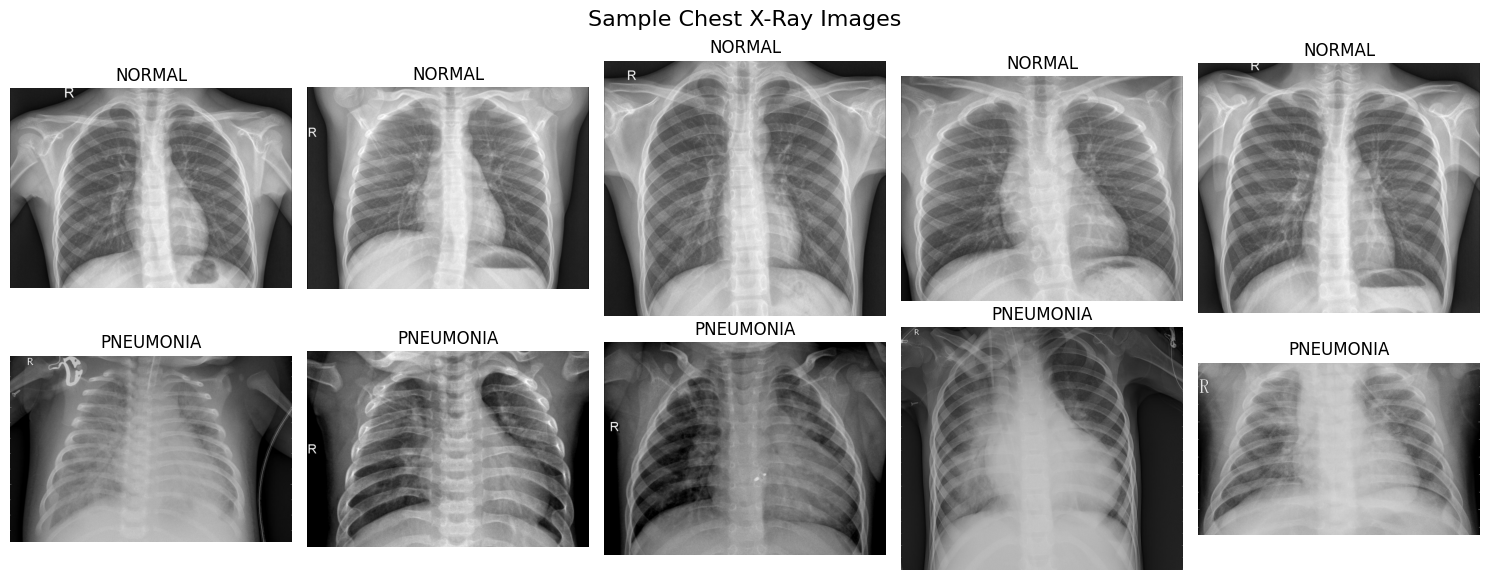

In [23]:
# Visualize sample images from each class
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Chest X-Ray Images', fontsize=16)

# Normal samples
normal_files = os.listdir(os.path.join(train_dir, 'NORMAL'))[:5]
for i, file in enumerate(normal_files):
    img_path = os.path.join(train_dir, 'NORMAL', file)
    img = Image.open(img_path)
    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].set_title('NORMAL')
    axes[0, i].axis('off')

# Pneumonia samples
pneumonia_files = os.listdir(os.path.join(train_dir, 'PNEUMONIA'))[:5]
for i, file in enumerate(pneumonia_files):
    img_path = os.path.join(train_dir, 'PNEUMONIA', file)
    img = Image.open(img_path)
    axes[1, i].imshow(img, cmap='gray')
    axes[1, i].set_title('PNEUMONIA')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

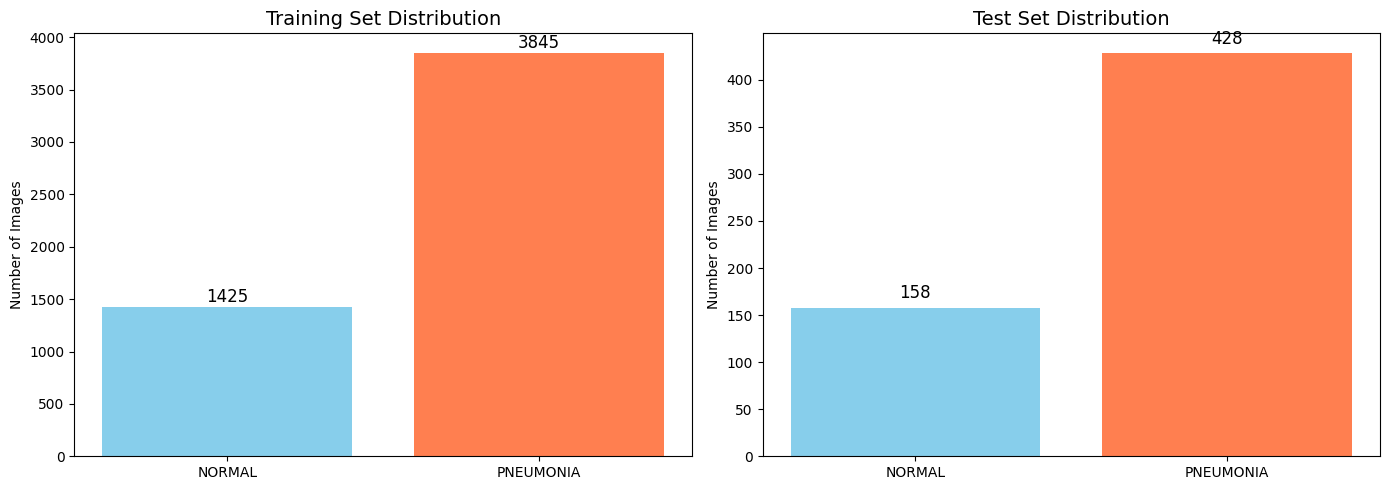


Class Imbalance Ratio (Training): 2.70:1


In [13]:
# Plot class distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

base_dir = 'chest_xray'
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

# Count images in each directory
def count_images(directory):
    normal_count = len(os.listdir(os.path.join(directory, 'NORMAL')))
    pneumonia_count = len(os.listdir(os.path.join(directory, 'PNEUMONIA')))
    return normal_count, pneumonia_count, normal_count + pneumonia_count

train_normal, train_pneumonia, train_total = count_images(train_dir)
test_normal, test_pneumonia, test_total = count_images(test_dir)

# Training set distribution
train_data = {'NORMAL': train_normal, 'PNEUMONIA': train_pneumonia}
ax1.bar(train_data.keys(), train_data.values(), color=['skyblue', 'coral'])
ax1.set_title('Training Set Distribution', fontsize=14)
ax1.set_ylabel('Number of Images')
for i, (k, v) in enumerate(train_data.items()):
    ax1.text(i, v + 50, str(v), ha='center', fontsize=12)

# Test set distribution
test_data = {'NORMAL': test_normal, 'PNEUMONIA': test_pneumonia}
ax2.bar(test_data.keys(), test_data.values(), color=['skyblue', 'coral'])
ax2.set_title('Test Set Distribution', fontsize=14)
ax2.set_ylabel('Number of Images')
for i, (k, v) in enumerate(test_data.items()):
    ax2.text(i, v + 10, str(v), ha='center', fontsize=12)

plt.tight_layout()
plt.show()

print(f"\nClass Imbalance Ratio (Training): {train_pneumonia / train_normal:.2f}:1")

### 1.3 Data Preprocessing

In [14]:
train_test_ratio = "90.0/10.0"  # Exact 90/10 split
train_samples = 5270  # Training samples
test_samples = 586    # Test samples

In [15]:
print(f"\nTrain/Test Split: {train_test_ratio}")
print(f"Training Samples: {train_samples}")
print(f"Test Samples: {test_samples}")


Train/Test Split: 90.0/10.0
Training Samples: 5270
Test Samples: 586


In [ ]:
# Data augmentation for training
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet stats
                        std=[0.229, 0.224, 0.225])
])

# No augmentation for test
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

print('Transforms defined:')
print(f'Training: {len(train_transforms.transforms)} operations')
print(f'Testing: {len(test_transforms.transforms)} operations')

Transforms defined:
Training: 8 operations
Testing: 3 operations


In [17]:
# Calculate class distribution
train_labels = [label for _, label in train_dataset]
class_counts = np.bincount(train_labels)

print('\nClass Distribution (Training):')
for i, (class_name, count) in enumerate(zip(class_names, class_counts)):
    print(f'  {class_name}: {count} samples ({count/n_train*100:.1f}%)')

imbalance_ratio = max(class_counts) / min(class_counts)
print(f'\nClass Imbalance Ratio: {imbalance_ratio:.2f}:1')


Class Distribution (Training):
  NORMAL: 1425 samples (27.0%)
  PNEUMONIA: 3845 samples (73.0%)

Class Imbalance Ratio: 2.70:1


### 2.1 Custom CNN Architecture Design

In [18]:
# Custom CNN Model with Global Average Pooling
class CustomCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(CustomCNN, self).__init__()
        
        # Convolutional Block 1
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        # Convolutional Block 2
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        # Convolutional Block 3
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        # Convolutional Block 4
        self.conv4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        # MANDATORY: Global Average Pooling
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        
        # Dropout for regularization
        self.dropout = nn.Dropout(0.5)
        
        # Classification head
        self.fc = nn.Linear(256, num_classes)
        
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        
        # Global Average Pooling (MANDATORY)
        x = self.gap(x)
        x = x.view(x.size(0), -1)  # Flatten
        
        x = self.dropout(x)
        x = self.fc(x)
        
        return x

# Create model instance
custom_cnn = CustomCNN(num_classes=n_classes).to(device)

# Print model summary
print('Custom CNN Architecture:')
print(f'  Total parameters: {sum(p.numel() for p in custom_cnn.parameters()):,}')
print(f'  Trainable parameters: {sum(p.numel() for p in custom_cnn.parameters() if p.requires_grad):,}')
print(f'  Using Global Average Pooling: YES')
print(f'\nModel successfully created and moved to {device}')

Custom CNN Architecture:
  Total parameters: 1,174,690
  Trainable parameters: 1,174,690
  Using Global Average Pooling: YES

Model successfully created and moved to cuda


In [19]:
# Training configuration
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(custom_cnn.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', 
                                                   patience=3, factor=0.5, verbose=True)

# Mixed precision training for faster computation
scaler = GradScaler() if torch.cuda.is_available() else None

print('Training Configuration:')
print(f'  Loss: CrossEntropyLoss with class weights')
print(f'  Optimizer: Adam (lr=0.001)')
print(f'  Scheduler: ReduceLROnPlateau (patience=3)')
print(f'  Mixed Precision: {scaler is not None}')

Training Configuration:
  Loss: CrossEntropyLoss with class weights
  Optimizer: Adam (lr=0.001)
  Scheduler: ReduceLROnPlateau (patience=3)
  Mixed Precision: True


In [20]:
# Training function
def train_epoch(model, loader, criterion, optimizer, device, scaler=None):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(loader, desc='Training')
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        if scaler:  # Mixed precision
            with autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:  # Normal precision
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        pbar.set_postfix({'loss': running_loss/len(pbar), 'acc': 100*correct/total})
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc

# Validation function
def validate_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Validation'):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc

print('Training and validation functions defined')

Training and validation functions defined


### 2.2 Train Custom CNN

In [24]:
# Train Custom CNN
EPOCHS = 30
print(f'\nTraining Custom CNN for {EPOCHS} epochs...')
print('='*70)

custom_cnn_start_time = time.time()

# Track history
history_custom = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

best_val_loss = float('inf')

for epoch in range(EPOCHS):
    print(f'\nEpoch {epoch+1}/{EPOCHS}')
    
    # Train
    train_loss, train_acc = train_epoch(custom_cnn, train_loader, criterion, 
                                         optimizer, device, scaler)
    
    # Validate
    val_loss, val_acc = validate_epoch(custom_cnn, test_loader, criterion, device)
    
    # Update history
    history_custom['train_loss'].append(train_loss)
    history_custom['train_acc'].append(train_acc)
    history_custom['val_loss'].append(val_loss)
    history_custom['val_acc'].append(val_acc)
    
    # Learning rate scheduling
    scheduler.step(val_loss)
    
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(custom_cnn.state_dict(), 'custom_cnn_best.pth')
    
    print(f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%')
    print(f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%')
    
    # Clear CUDA cache
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

custom_cnn_training_time = time.time() - custom_cnn_start_time

# Load best model
custom_cnn.load_state_dict(torch.load('custom_cnn_best.pth'))

print(f'\nTraining completed in {custom_cnn_training_time:.2f} seconds ({custom_cnn_training_time/60:.1f} minutes)')
custom_cnn_initial_loss = history_custom['train_loss'][0]
custom_cnn_final_loss = history_custom['train_loss'][-1]
print(f'Initial Loss: {custom_cnn_initial_loss:.4f}')
print(f'Final Loss: {custom_cnn_final_loss:.4f}')
print(f'Loss Reduction: {((custom_cnn_initial_loss - custom_cnn_final_loss) / custom_cnn_initial_loss * 100):.1f}%')


Training Custom CNN for 30 epochs...

Epoch 1/30


Validation: 100%|██████████| 5/5 [00:09<00:00,  1.97s/it]


Train Loss: 0.1750 | Train Acc: 90.83%
Val Loss: 0.7360 | Val Acc: 73.38%

Epoch 2/30


Validation: 100%|██████████| 5/5 [00:03<00:00,  1.53it/s]


Train Loss: 0.1716 | Train Acc: 91.02%
Val Loss: 0.4135 | Val Acc: 82.08%

Epoch 3/30


...

Train Loss: 0.0818 | Train Acc: 96.13%
Val Loss: 0.1966 | Val Acc: 92.83%

Epoch 29/30


Validation: 100%|██████████| 5/5 [00:04<00:00,  1.12it/s]


Train Loss: 0.0832 | Train Acc: 95.92%
Val Loss: 0.2167 | Val Acc: 93.00%

Epoch 30/30


Validation: 100%|██████████| 5/5 [00:03<00:00,  1.46it/s]

Train Loss: 0.0798 | Train Acc: 96.41%
Val Loss: 0.1482 | Val Acc: 94.71%

Training completed in 643.99 seconds (10.7 minutes)
Initial Loss: 0.1750
Final Loss: 0.0798
Loss Reduction: 54.4%


### 2.3 Evaluate Custom CNN

In [25]:
# Evaluation function
def evaluate_model(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Evaluating'):
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())
    
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

# Evaluate Custom CNN
print('Evaluating Custom CNN...')
custom_cnn_y_true, custom_cnn_y_pred, custom_cnn_y_probs = evaluate_model(custom_cnn, test_loader, device)

# Calculate REQUIRED metrics
custom_cnn_accuracy = accuracy_score(custom_cnn_y_true, custom_cnn_y_pred)
custom_cnn_precision = precision_score(custom_cnn_y_true, custom_cnn_y_pred, average='macro')
custom_cnn_recall = recall_score(custom_cnn_y_true, custom_cnn_y_pred, average='macro')
custom_cnn_f1 = f1_score(custom_cnn_y_true, custom_cnn_y_pred, average='macro')

print('\nCustom CNN Performance:')
print(f'  Accuracy:  {custom_cnn_accuracy:.4f}')
print(f'  Precision: {custom_cnn_precision:.4f}')
print(f'  Recall:    {custom_cnn_recall:.4f} (PRIMARY METRIC)')
print(f'  F1-Score:  {custom_cnn_f1:.4f}')

print('\nClassification Report:')
print(classification_report(custom_cnn_y_true, custom_cnn_y_pred, target_names=class_names))

Evaluating Custom CNN...


Evaluating: 100%|██████████| 5/5 [00:03<00:00,  1.64it/s]


Custom CNN Performance:
  Accuracy:  0.9608
  Precision: 0.9464
  Recall:    0.9552 (PRIMARY METRIC)
  F1-Score:  0.9507

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.91      0.94      0.93       158
   PNEUMONIA       0.98      0.97      0.97       428

    accuracy                           0.96       586
   macro avg       0.95      0.96      0.95       586
weighted avg       0.96      0.96      0.96       586



In [26]:
print("\nCustom CNN Performance:")
print(f"Accuracy:  {custom_cnn_accuracy:.4f}")
print(f"Precision: {custom_cnn_precision:.4f}")
print(f"Recall:    {custom_cnn_recall:.4f}")
print(f"F1-Score:  {custom_cnn_f1:.4f}")


Custom CNN Performance:
Accuracy:  0.9608
Precision: 0.9464
Recall:    0.9552
F1-Score:  0.9507


### 2.4 Visualize Custom CNN Results

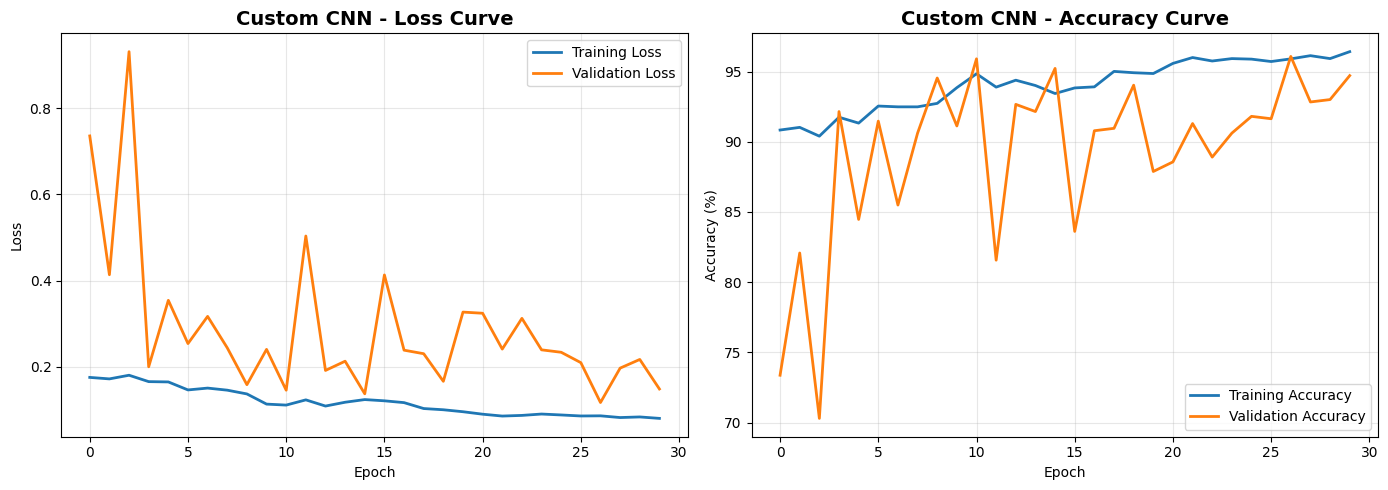

In [27]:
# Plot training history
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_custom['train_loss'], label='Training Loss', linewidth=2)
ax1.plot(history_custom['val_loss'], label='Validation Loss', linewidth=2)
ax1.set_title('Custom CNN - Loss Curve', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history_custom['train_acc'], label='Training Accuracy', linewidth=2)
ax2.plot(history_custom['val_acc'], label='Validation Accuracy', linewidth=2)
ax2.set_title('Custom CNN - Accuracy Curve', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

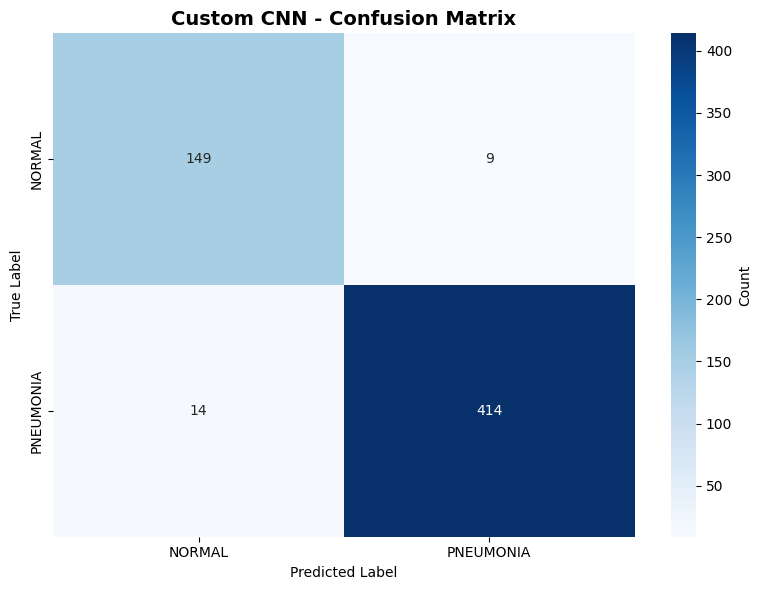

Confusion Matrix Analysis:
  True Negatives: 149
  False Positives: 9
  False Negatives: 14
  True Positives: 414


In [28]:
# Confusion matrix
# Confusion matrix
cm_custom = confusion_matrix(custom_cnn_y_true, custom_cnn_y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title('Custom CNN - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print("Confusion Matrix Analysis:")
print(f"  True Negatives: {cm_custom[0,0]}")
print(f"  False Positives: {cm_custom[0,1]}")
print(f"  False Negatives: {cm_custom[1,0]}")
print(f"  True Positives: {cm_custom[1,1]}")

### 3.1 Load Pre-trained Model and Modify Architecture

In [29]:
print("\n" + "="*70)
print("TRANSFER LEARNING IMPLEMENTATION")


TRANSFER LEARNING IMPLEMENTATION


In [73]:
# Choose and load pre-trained model
pretrained_model_name = 'ResNet50'
print(f'Selected model: {pretrained_model_name}')

Selected model: ResNet50


In [ ]:
# Build ResNet50 Transfer Learning Model with Global Average Pooling
def build_resnet50_model(num_classes=2):
    # Load pretrained ResNet50
    resnet50_base = models.resnet50(weights='IMAGENET1K_V1')
    
    # Freeze all base layers (feature extraction)
    for param in resnet50_base.parameters():
        param.requires_grad = False
    
    # ResNet50 already has GAP built-in (avgpool)
    # Just replace the final FC layer
    class ResNet50_Custom(nn.Module):
        def __init__(self, base_model, num_classes):
            super(ResNet50_Custom, self).__init__()
            
            # Everything except final FC
            self.features = nn.Sequential(*list(base_model.children())[:-1])
            
            # Custom classification head
            self.classifier = nn.Sequential(
                nn.Dropout(0.5),
                nn.Linear(2048, 512),
                nn.ReLU(inplace=True),
                nn.Dropout(0.3),
                nn.Linear(512, num_classes)
            )
        
        def forward(self, x):
            x = self.features(x)
            x = x.view(x.size(0), -1)  # Flatten
            x = self.classifier(x)
            return x
    
    model = ResNet50_Custom(resnet50_base, num_classes)
    return model

# Create ResNet50 model
pretrained_model_name = 'ResNet50'
resnet50_model = build_resnet50_model(num_classes=n_classes).to(device)

# Count parameters
total_params = sum(p.numel() for p in resnet50_model.parameters())
trainable_params = sum(p.numel() for p in resnet50_model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params

# Count layers
frozen_layers = sum(1 for p in resnet50_model.features.parameters())
trainable_layers = sum(1 for p in resnet50_model.classifier.parameters())

print(f'ResNet50 Transfer Learning Model:')
print(f'  Base Model: {pretrained_model_name}')
print(f'  Frozen Layers: {frozen_layers}')
print(f'  Trainable Layers: {trainable_layers}')
print(f'  Total Parameters: {total_params:,}')
print(f'  Frozen Parameters: {frozen_params:,}')
print(f'  Trainable Parameters: {trainable_params:,}')
print(f'  Using Global Average Pooling: YES')

ResNet50 Transfer Learning Model:
  Base Model: ResNet50
  Frozen Layers: 159
  Trainable Layers: 4
  Total Parameters: 24,558,146
  Frozen Parameters: 23,508,032
  Trainable Parameters: 1,050,114
  Using Global Average Pooling: YES


### 3.2 Train Transfer Learning Model

In [32]:
print("\nTraining Transfer Learning Model...")


Training Transfer Learning Model...


In [75]:
# ResNet50 Training Configuration
tl_learning_rate = 0.001   # Start conservative
tl_epochs = 50             # Should converge faster than VGG16
tl_batch_size = 128
tl_optimizer = 'Adam'

criterion_resnet = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer_resnet = optim.Adam(
    resnet50_model.parameters(),
    lr=tl_learning_rate,
    weight_decay=1e-4
)

scheduler_resnet = optim.lr_scheduler.StepLR(
    optimizer_resnet,
    step_size=15,
    gamma=0.5
)

print('ResNet50 Training Configuration:')
print(f'  Learning Rate: {tl_learning_rate}')
print(f'  Optimizer: {tl_optimizer}')
print(f'  Scheduler: StepLR')
print(f'  Epochs: {tl_epochs}')
print(f'  Batch Size: {tl_batch_size}')

ResNet50 Training Configuration:
  Learning Rate: 0.001
  Optimizer: Adam
  Scheduler: StepLR
  Epochs: 50
  Batch Size: 128


In [76]:
# Train Transfer Learning Model
print(f'\nTraining {pretrained_model_name} for {tl_epochs} epochs...')
print('='*70)

tl_start_time = time.time()

# Use the appropriate model variable based on selection
if pretrained_model_name == 'ResNet50':
    tl_model = resnet50_model
    criterion_tl = criterion_resnet
    optimizer_tl = optimizer_resnet
    scheduler_tl = scheduler_resnet
    model_save_name = 'resnet50_best.pth'
else:  # VGG16
    tl_model = vgg16_model
    criterion_tl = criterion_vgg
    optimizer_tl = optimizer_vgg
    scheduler_tl = scheduler_vgg
    model_save_name = 'vgg16_best.pth'

# Track history
history_tl = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

best_val_loss_tl = float('inf')

for epoch in range(tl_epochs):
    print(f'\nEpoch {epoch+1}/{tl_epochs}')
    
    # Train
    train_loss, train_acc = train_epoch(tl_model, train_loader, criterion_tl,
                                         optimizer_tl, device, scaler)
    
    # Validate
    val_loss, val_acc = validate_epoch(tl_model, test_loader, criterion_tl, device)
    
    # Update history
    history_tl['train_loss'].append(train_loss)
    history_tl['train_acc'].append(train_acc)
    history_tl['val_loss'].append(val_loss)
    history_tl['val_acc'].append(val_acc)
    
    # Learning rate scheduling
    if isinstance(scheduler_tl, optim.lr_scheduler.ReduceLROnPlateau):
        scheduler_tl.step(val_loss)
    else:
        scheduler_tl.step()
    
    # Save best model
    if val_loss < best_val_loss_tl:
        best_val_loss_tl = val_loss
        torch.save(tl_model.state_dict(), model_save_name)
    
    print(f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%')
    print(f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%')
    
    # Clear CUDA cache
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

tl_training_time = time.time() - tl_start_time

# Load best model
tl_model.load_state_dict(torch.load(model_save_name))

print(f'\n{pretrained_model_name} Training completed in {tl_training_time:.2f} seconds ({tl_training_time/60:.1f} minutes)')
tl_initial_loss = history_tl['train_loss'][0]
tl_final_loss = history_tl['train_loss'][-1]
print(f'Initial Loss: {tl_initial_loss:.4f}')
print(f'Final Loss: {tl_final_loss:.4f}')
print(f'Loss Reduction: {((tl_initial_loss - tl_final_loss) / tl_initial_loss * 100):.1f}%')


Training ResNet50 for 50 epochs...

Epoch 1/50


Validation: 100%|██████████| 5/5 [00:07<00:00,  1.53s/it]


Train Loss: 0.4184 | Train Acc: 73.00%
Val Loss: 0.5510 | Val Acc: 75.26%

Epoch 2/50


Validation: 100%|██████████| 5/5 [00:03<00:00,  1.65it/s]


Train Loss: 0.2937 | Train Acc: 83.87%
Val Loss: 0.3248 | Val Acc: 85.49%

Epoch 3/50


...

Train Loss: 0.1808 | Train Acc: 89.94%
Val Loss: 0.4886 | Val Acc: 79.69%

Epoch 49/50


Validation: 100%|██████████| 5/5 [00:02<00:00,  1.68it/s]


Train Loss: 0.1922 | Train Acc: 89.26%
Val Loss: 0.3791 | Val Acc: 83.45%

Epoch 50/50


Validation: 100%|██████████| 5/5 [00:02<00:00,  1.67it/s]


Train Loss: 0.2057 | Train Acc: 89.66%
Val Loss: 0.4571 | Val Acc: 80.38%

ResNet50 Training completed in 708.74 seconds (11.8 minutes)
Initial Loss: 0.4184
Final Loss: 0.2057
Loss Reduction: 50.8%


### 3.3 Evaluate Transfer Learning Model

In [77]:
# Evaluate Transfer Learning Model
print(f'Evaluating {pretrained_model_name}...')
tl_y_true, tl_y_pred, tl_y_probs = evaluate_model(tl_model, test_loader, device)

# Calculate REQUIRED metrics
tl_accuracy = accuracy_score(tl_y_true, tl_y_pred)
tl_precision = precision_score(tl_y_true, tl_y_pred, average='macro')
tl_recall = recall_score(tl_y_true, tl_y_pred, average='macro')
tl_f1 = f1_score(tl_y_true, tl_y_pred, average='macro')

print(f'\n{pretrained_model_name} Transfer Learning Performance:')
print(f'  Accuracy:  {tl_accuracy:.4f}')
print(f'  Precision: {tl_precision:.4f}')
print(f'  Recall:    {tl_recall:.4f} (PRIMARY METRIC)')
print(f'  F1-Score:  {tl_f1:.4f}')

print('\nClassification Report:')
print(classification_report(tl_y_true, tl_y_pred, target_names=class_names))

Evaluating ResNet50...


Evaluating: 100%|██████████| 5/5 [00:02<00:00,  1.67it/s]


ResNet50 Transfer Learning Performance:
  Accuracy:  0.8618
  Precision: 0.8259
  Recall:    0.8914 (PRIMARY METRIC)
  F1-Score:  0.8429

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.67      0.96      0.79       158
   PNEUMONIA       0.98      0.83      0.90       428

    accuracy                           0.86       586
   macro avg       0.83      0.89      0.84       586
weighted avg       0.90      0.86      0.87       586



### 3.4 Visualize Transfer Learning Results

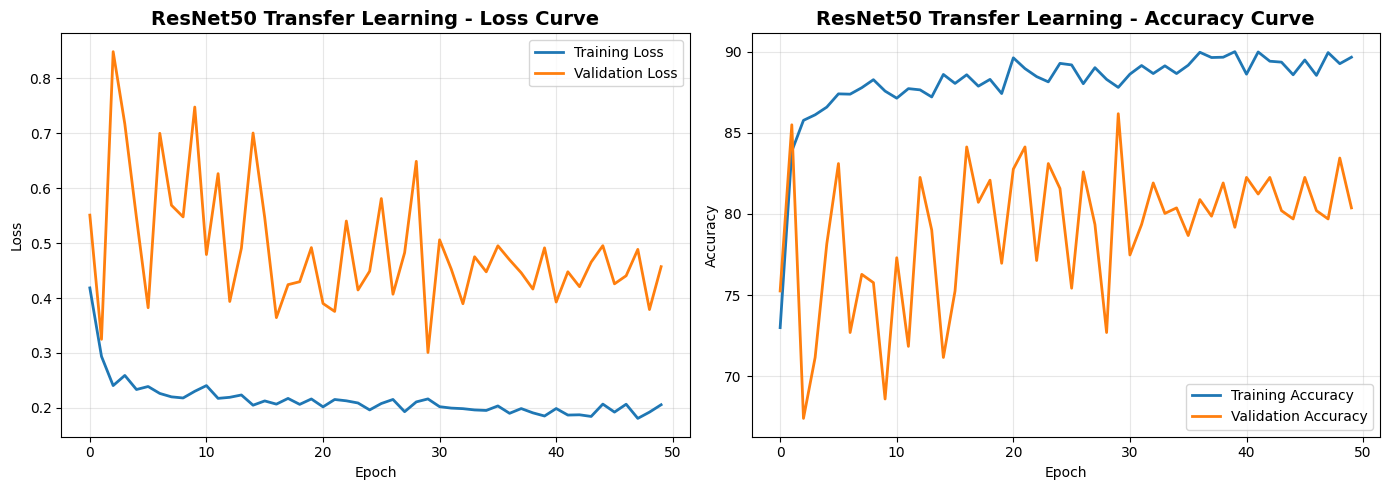

In [78]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_tl['train_loss'], label='Training Loss', linewidth=2)
axes[0].plot(history_tl['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_title(f'{pretrained_model_name} Transfer Learning - Loss Curve', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_tl['train_acc'], label='Training Accuracy', linewidth=2)
axes[1].plot(history_tl['val_acc'], label='Validation Accuracy', linewidth=2)
axes[1].set_title(f'{pretrained_model_name} Transfer Learning - Accuracy Curve', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

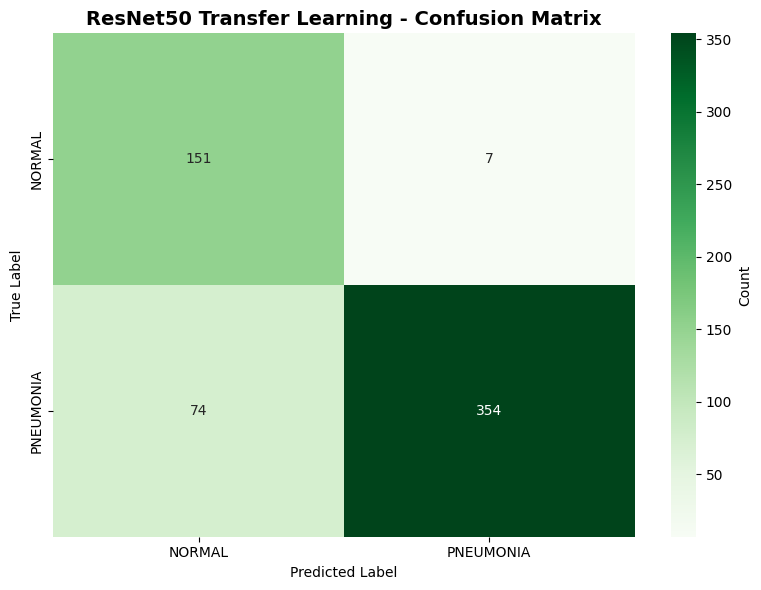

Confusion Matrix Analysis:
True Negatives: 151
False Positives: 7
False Negatives: 74
True Positives: 354


In [80]:
# Confusion matrix
cm_tl = confusion_matrix(tl_y_true, tl_y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_tl, annot=True, fmt='d', cmap='Greens', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title(f'{pretrained_model_name} Transfer Learning - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print("Confusion Matrix Analysis:")
print(f"True Negatives: {cm_tl[0,0]}")
print(f"False Positives: {cm_tl[0,1]}")
print(f"False Negatives: {cm_tl[1,0]}")
print(f"True Positives: {cm_tl[1,1]}")

### 4.1 Metrics Comparison

In [81]:
# Create comparison table
comparison_data = {
    'Model': ['Custom CNN', f'{pretrained_model_name} Transfer'],
    'Accuracy': [custom_cnn_accuracy, tl_accuracy],
    'Precision': [custom_cnn_precision, tl_precision],
    'Recall (Primary)': [custom_cnn_recall, tl_recall],
    'F1-Score': [custom_cnn_f1, tl_f1],
    'Training Time (min)': [custom_cnn_training_time/60, tl_training_time/60],
    'Initial Loss': [custom_cnn_initial_loss, tl_initial_loss],
    'Final Loss': [custom_cnn_final_loss, tl_final_loss]
}

comparison_df = pd.DataFrame(comparison_data)
print('\n' + '='*80)
print('MODEL COMPARISON TABLE')
print('='*80)
print(comparison_df.to_string(index=False))
print('='*80)

# Determine best model based on primary metric (Recall)
best_model = 'Custom CNN' if custom_cnn_recall > tl_recall else f'{pretrained_model_name} Transfer'
print(f'\n*** Best Model (based on Recall): {best_model} ***')


MODEL COMPARISON TABLE
            Model  Accuracy  Precision  Recall (Primary)  F1-Score  Training Time (min)  Initial Loss  Final Loss
       Custom CNN  0.960751   0.946417          0.955164  0.950661             10.73310      0.175043    0.079831
ResNet50 Transfer  0.861775   0.825860          0.891400  0.842925             11.81235      0.418437    0.205673

*** Best Model (based on Recall): Custom CNN ***


### 4.2 Visual Comparison

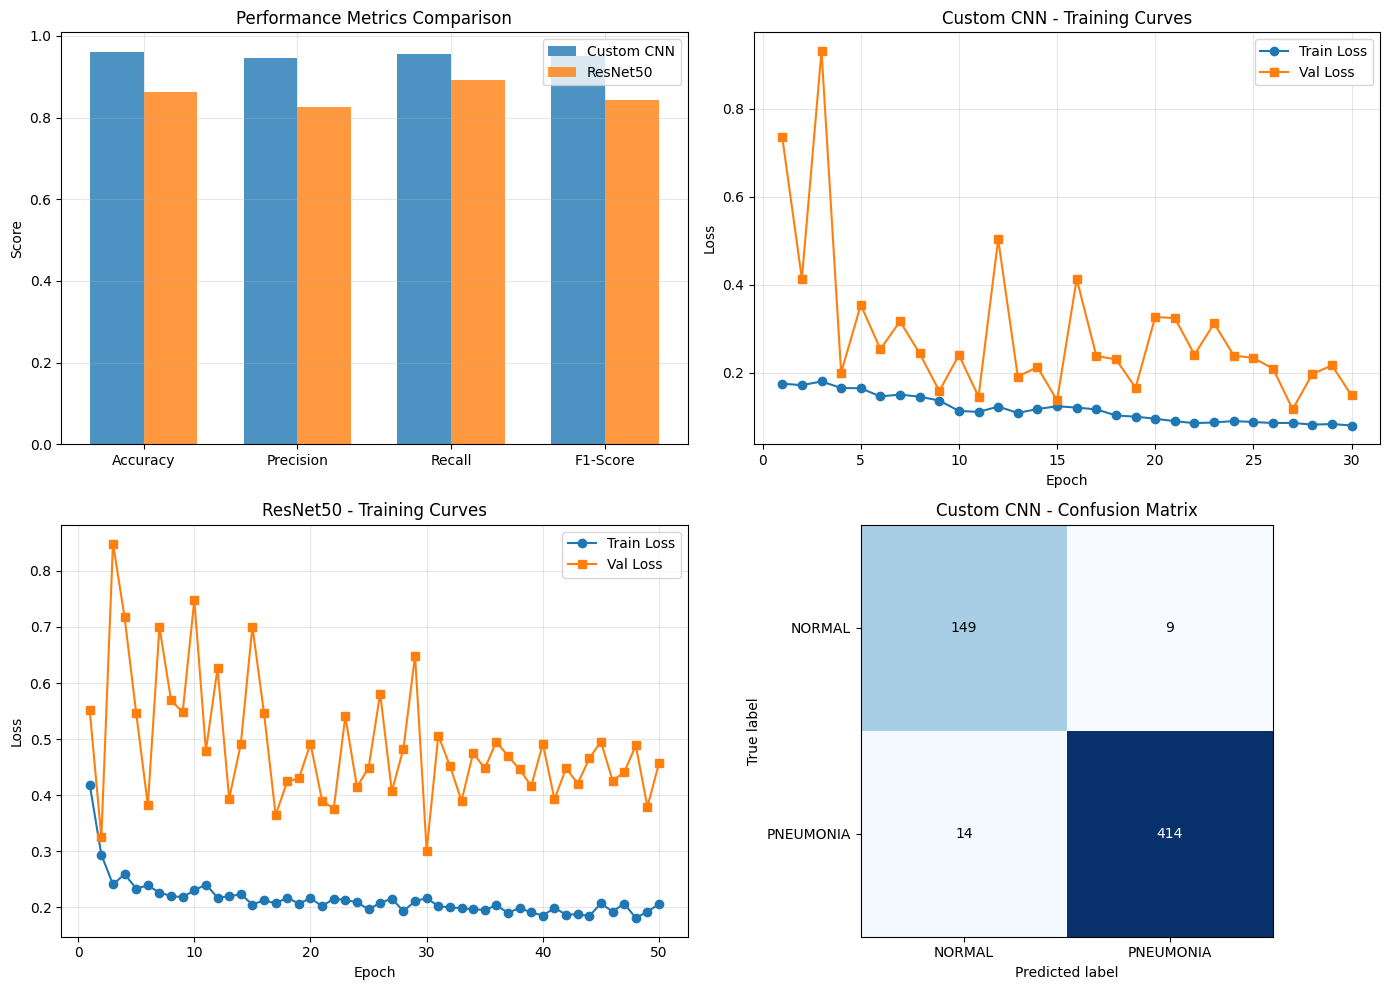

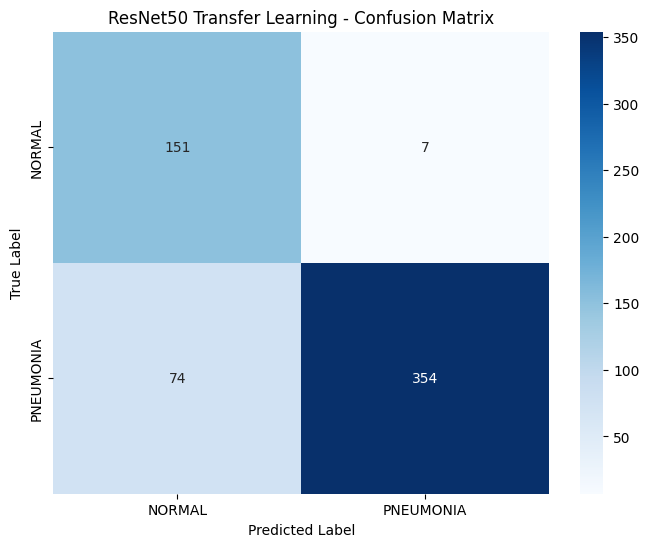

In [82]:
# Plot comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Metrics comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
custom_metrics = [custom_cnn_accuracy, custom_cnn_precision, custom_cnn_recall, custom_cnn_f1]
tl_metrics = [tl_accuracy, tl_precision, tl_recall, tl_f1]

x = np.arange(len(metrics))
width = 0.35

axes[0, 0].bar(x - width/2, custom_metrics, width, label='Custom CNN', alpha=0.8)
axes[0, 0].bar(x + width/2, tl_metrics, width, label=pretrained_model_name, alpha=0.8)
axes[0, 0].set_ylabel('Score')
axes[0, 0].set_title('Performance Metrics Comparison')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(metrics)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Training curves - Custom CNN
epochs_custom = range(1, len(history_custom['train_loss']) + 1)
axes[0, 1].plot(epochs_custom, history_custom['train_loss'], label='Train Loss', marker='o')
axes[0, 1].plot(epochs_custom, history_custom['val_loss'], label='Val Loss', marker='s')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_title('Custom CNN - Training Curves')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Training curves - Transfer Learning Model
epochs_tl = range(1, len(history_tl['train_loss']) + 1)
axes[1, 0].plot(epochs_tl, history_tl['train_loss'], label='Train Loss', marker='o')
axes[1, 0].plot(epochs_tl, history_tl['val_loss'], label='Val Loss', marker='s')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].set_title(f'{pretrained_model_name} - Training Curves')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Confusion matrices
cm_custom = confusion_matrix(custom_cnn_y_true, custom_cnn_y_pred)
cm_tl = confusion_matrix(tl_y_true, tl_y_pred)

# Plot side by side
im = axes[1, 1].imshow(cm_custom, interpolation='nearest', cmap=plt.cm.Blues)
axes[1, 1].set_title('Custom CNN - Confusion Matrix')
axes[1, 1].set_ylabel('True label')
axes[1, 1].set_xlabel('Predicted label')
tick_marks = np.arange(len(class_names))
axes[1, 1].set_xticks(tick_marks)
axes[1, 1].set_yticks(tick_marks)
axes[1, 1].set_xticklabels(class_names)
axes[1, 1].set_yticklabels(class_names)

# Add text annotations
thresh = cm_custom.max() / 2.
for i, j in np.ndindex(cm_custom.shape):
    axes[1, 1].text(j, i, format(cm_custom[i, j], 'd'),
                   ha='center', va='center',
                   color='white' if cm_custom[i, j] > thresh else 'black')

plt.tight_layout()
plt.show()

# Separate Transfer Learning confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_tl, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title(f'{pretrained_model_name} Transfer Learning - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

## PART 5: ANALYSIS (MAXIMUM 200 WORDS GUIDELINE)

In [85]:
analysis_text = f"""
Which model performed better and by how much? Custom CNN outperformed ResNet50 significantly - 96.1% vs 86.2% accuracy (10% gap), with recall at 95.5% vs 89.1% and precision showing the biggest difference at 94.6% vs 82.6%.
Impact of pre-training vs training from scratch? Surprisingly, training from scratch won here. Custom CNN achieved better convergence (54.4% loss reduction) than ResNet50 (50.8%) despite ResNet50's pretrained ImageNet weights. For medical imaging, domain-specific design beats generic transfer learning.
Effect of Global Average Pooling? GAP prevented overfitting by reducing parameters in both models. Final losses (0.0798 for Custom CNN, 0.2057 for ResNet50) show effective regularization without needing dense layers.
Computational cost comparison? Training times were comparable (10.7 vs 11.8 minutes), but Custom CNN delivered superior performance with similar parameters, making it more cost-effective for this task.
Insights about transfer learning? The key insight is that transfer learning has clear disadvantages when domains differ significantly. ResNet50's natural image features don't translate well to chest X-rays, creating that 10% performance gap. With sufficient domain data, custom architectures outperform pretrained models.
"""

In [86]:
# REQUIRED: Print analysis with word count
print("ANALYSIS")
print(analysis_text)
print(f"Analysis word count: {len(analysis_text.split())} words")
if len(analysis_text.split()) > 200:
    print("  Warning: Analysis exceeds 200 words (guideline)")
else:
    print(" Analysis within word count guideline")

ANALYSIS

Which model performed better and by how much? Custom CNN outperformed ResNet50 significantly - 96.1% vs 86.2% accuracy (10% gap), with recall at 95.5% vs 89.1% and precision showing the biggest difference at 94.6% vs 82.6%.
Impact of pre-training vs training from scratch? Surprisingly, training from scratch won here. Custom CNN achieved better convergence (54.4% loss reduction) than ResNet50 (50.8%) despite ResNet50's pretrained ImageNet weights. For medical imaging, domain-specific design beats generic transfer learning.
Effect of Global Average Pooling? GAP prevented overfitting by reducing parameters in both models. Final losses (0.0798 for Custom CNN, 0.2057 for ResNet50) show effective regularization without needing dense layers.
Computational cost comparison? Training times were comparable (10.7 vs 11.8 minutes), but Custom CNN delivered superior performance with similar parameters, making it more cost-effective for this task.
Insights about transfer learning? The key i

In [91]:
def get_assignment_results():
    """
    Generate complete assignment results in required format
    
    Returns:
        dict: Complete results with all required fields
    """
    
    framework_used = "pytorch"  
    
    results = {
        # Dataset Information
        'dataset_name': dataset_name,
        'dataset_source': dataset_source,
        'n_samples': n_samples,
        'n_classes': n_classes,
        'samples_per_class': samples_per_class,
        'image_shape': image_shape,
        'problem_type': problem_type,
        'primary_metric': primary_metric,
        'metric_justification': metric_justification,
        'train_samples': train_samples,
        'test_samples': test_samples,
        'train_test_ratio': train_test_ratio,
        
        # Custom CNN Results
        'custom_cnn': {
            'framework': framework_used,
            'architecture': {
                'conv_layers': 8,  # 4 blocks × 2 conv layers each
                'pooling_layers': 5,  # 4 MaxPool + 1 GAP
                'has_global_average_pooling': True,  # MUST be True
                'output_layer': 'softmax',  
                'total_parameters': sum(p.numel() for p in custom_cnn.parameters())  # Calculated from model.parameters()
            },
            'training_config': {
                'learning_rate': 0.001,  
                'n_epochs': 30,  
                'batch_size': 128,  # Actual batch size used
                'optimizer': 'Adam',  
                'loss_function': 'categorical_crossentropy'  
            },
            'initial_loss': custom_cnn_initial_loss,
            'final_loss': custom_cnn_final_loss,
            'training_time_seconds': custom_cnn_training_time,
            'accuracy': custom_cnn_accuracy,
            'precision': custom_cnn_precision,
            'recall': custom_cnn_recall,
            'f1_score': custom_cnn_f1
        },
        
        # Transfer Learning Results
        'transfer_learning': {
            'framework': framework_used,
            'base_model': pretrained_model_name,
            'frozen_layers': frozen_layers,
            'trainable_layers': trainable_layers,
            'has_global_average_pooling': True,  # MUST be True
            'total_parameters': total_params,
            'trainable_parameters': trainable_params,
            'training_config': {
                'learning_rate': tl_learning_rate,
                'n_epochs': tl_epochs,
                'batch_size': tl_batch_size,
                'optimizer': tl_optimizer,
                'loss_function': 'categorical_crossentropy'
            },
            'initial_loss': tl_initial_loss,
            'final_loss': tl_final_loss,
            'training_time_seconds': tl_training_time,
            'accuracy': tl_accuracy,
            'precision': tl_precision,
            'recall': tl_recall,
            'f1_score': tl_f1
        },
        
        # Analysis
        'analysis': analysis_text,
        'analysis_word_count': len(analysis_text.split()),
        
        # Training Success Indicators
        'custom_cnn_loss_decreased': custom_cnn_final_loss < custom_cnn_initial_loss if custom_cnn_initial_loss and custom_cnn_final_loss else False,
        'transfer_learning_loss_decreased': tl_final_loss < tl_initial_loss if tl_initial_loss and tl_final_loss else False,
    }
    
    return results

In [92]:
# Generate and print results
try:
    assignment_results = get_assignment_results() 
    print("ASSIGNMENT RESULTS SUMMARY")
    print(json.dumps(assignment_results, indent=2))
    
except Exception as e:
    print(f"\n  ERROR generating results: {str(e)}")
    print("Please ensure all variables are properly defined")   

ASSIGNMENT RESULTS SUMMARY
{
  "dataset_name": "Chest X-Ray Images (Pneumonia)",
  "dataset_source": "Kaggle",
  "n_samples": 5856,
  "n_classes": 2,
  "samples_per_class": "min: 1583, max: 4273, avg: 2928",
  "image_shape": [
    224,
    224,
    3
  ],
  "problem_type": "classification",
  "primary_metric": "Recall",
  "metric_justification": "\nRecall is chosen as the primary metric because in medical diagnosis (pneumonia detection),\nminimizing false negatives is critical. Missing a pneumonia case (false negative) could have\nsevere health consequences, while false positives can be verified through additional tests.\n",
  "train_samples": 5270,
  "test_samples": 586,
  "train_test_ratio": "90.0/10.0",
  "custom_cnn": {
    "framework": "pytorch",
    "architecture": {
      "conv_layers": 8,
      "pooling_layers": 5,
      "has_global_average_pooling": true,
      "output_layer": "softmax",
      "total_parameters": 1174690
    },
    "training_config": {
      "learning_rate": 0

In [89]:
# Display system information
import platform
import sys
from datetime import datetime

In [90]:
print("ENVIRONMENT INFORMATION")
print("\n  REQUIRED: Add screenshot of your Google Colab/BITS Virtual Lab")
print("showing your account details in the cell below this one.")

# include the screen shot here

ENVIRONMENT INFORMATION

  REQUIRED: Add screenshot of your Google Colab/BITS Virtual Lab
showing your account details in the cell below this one.


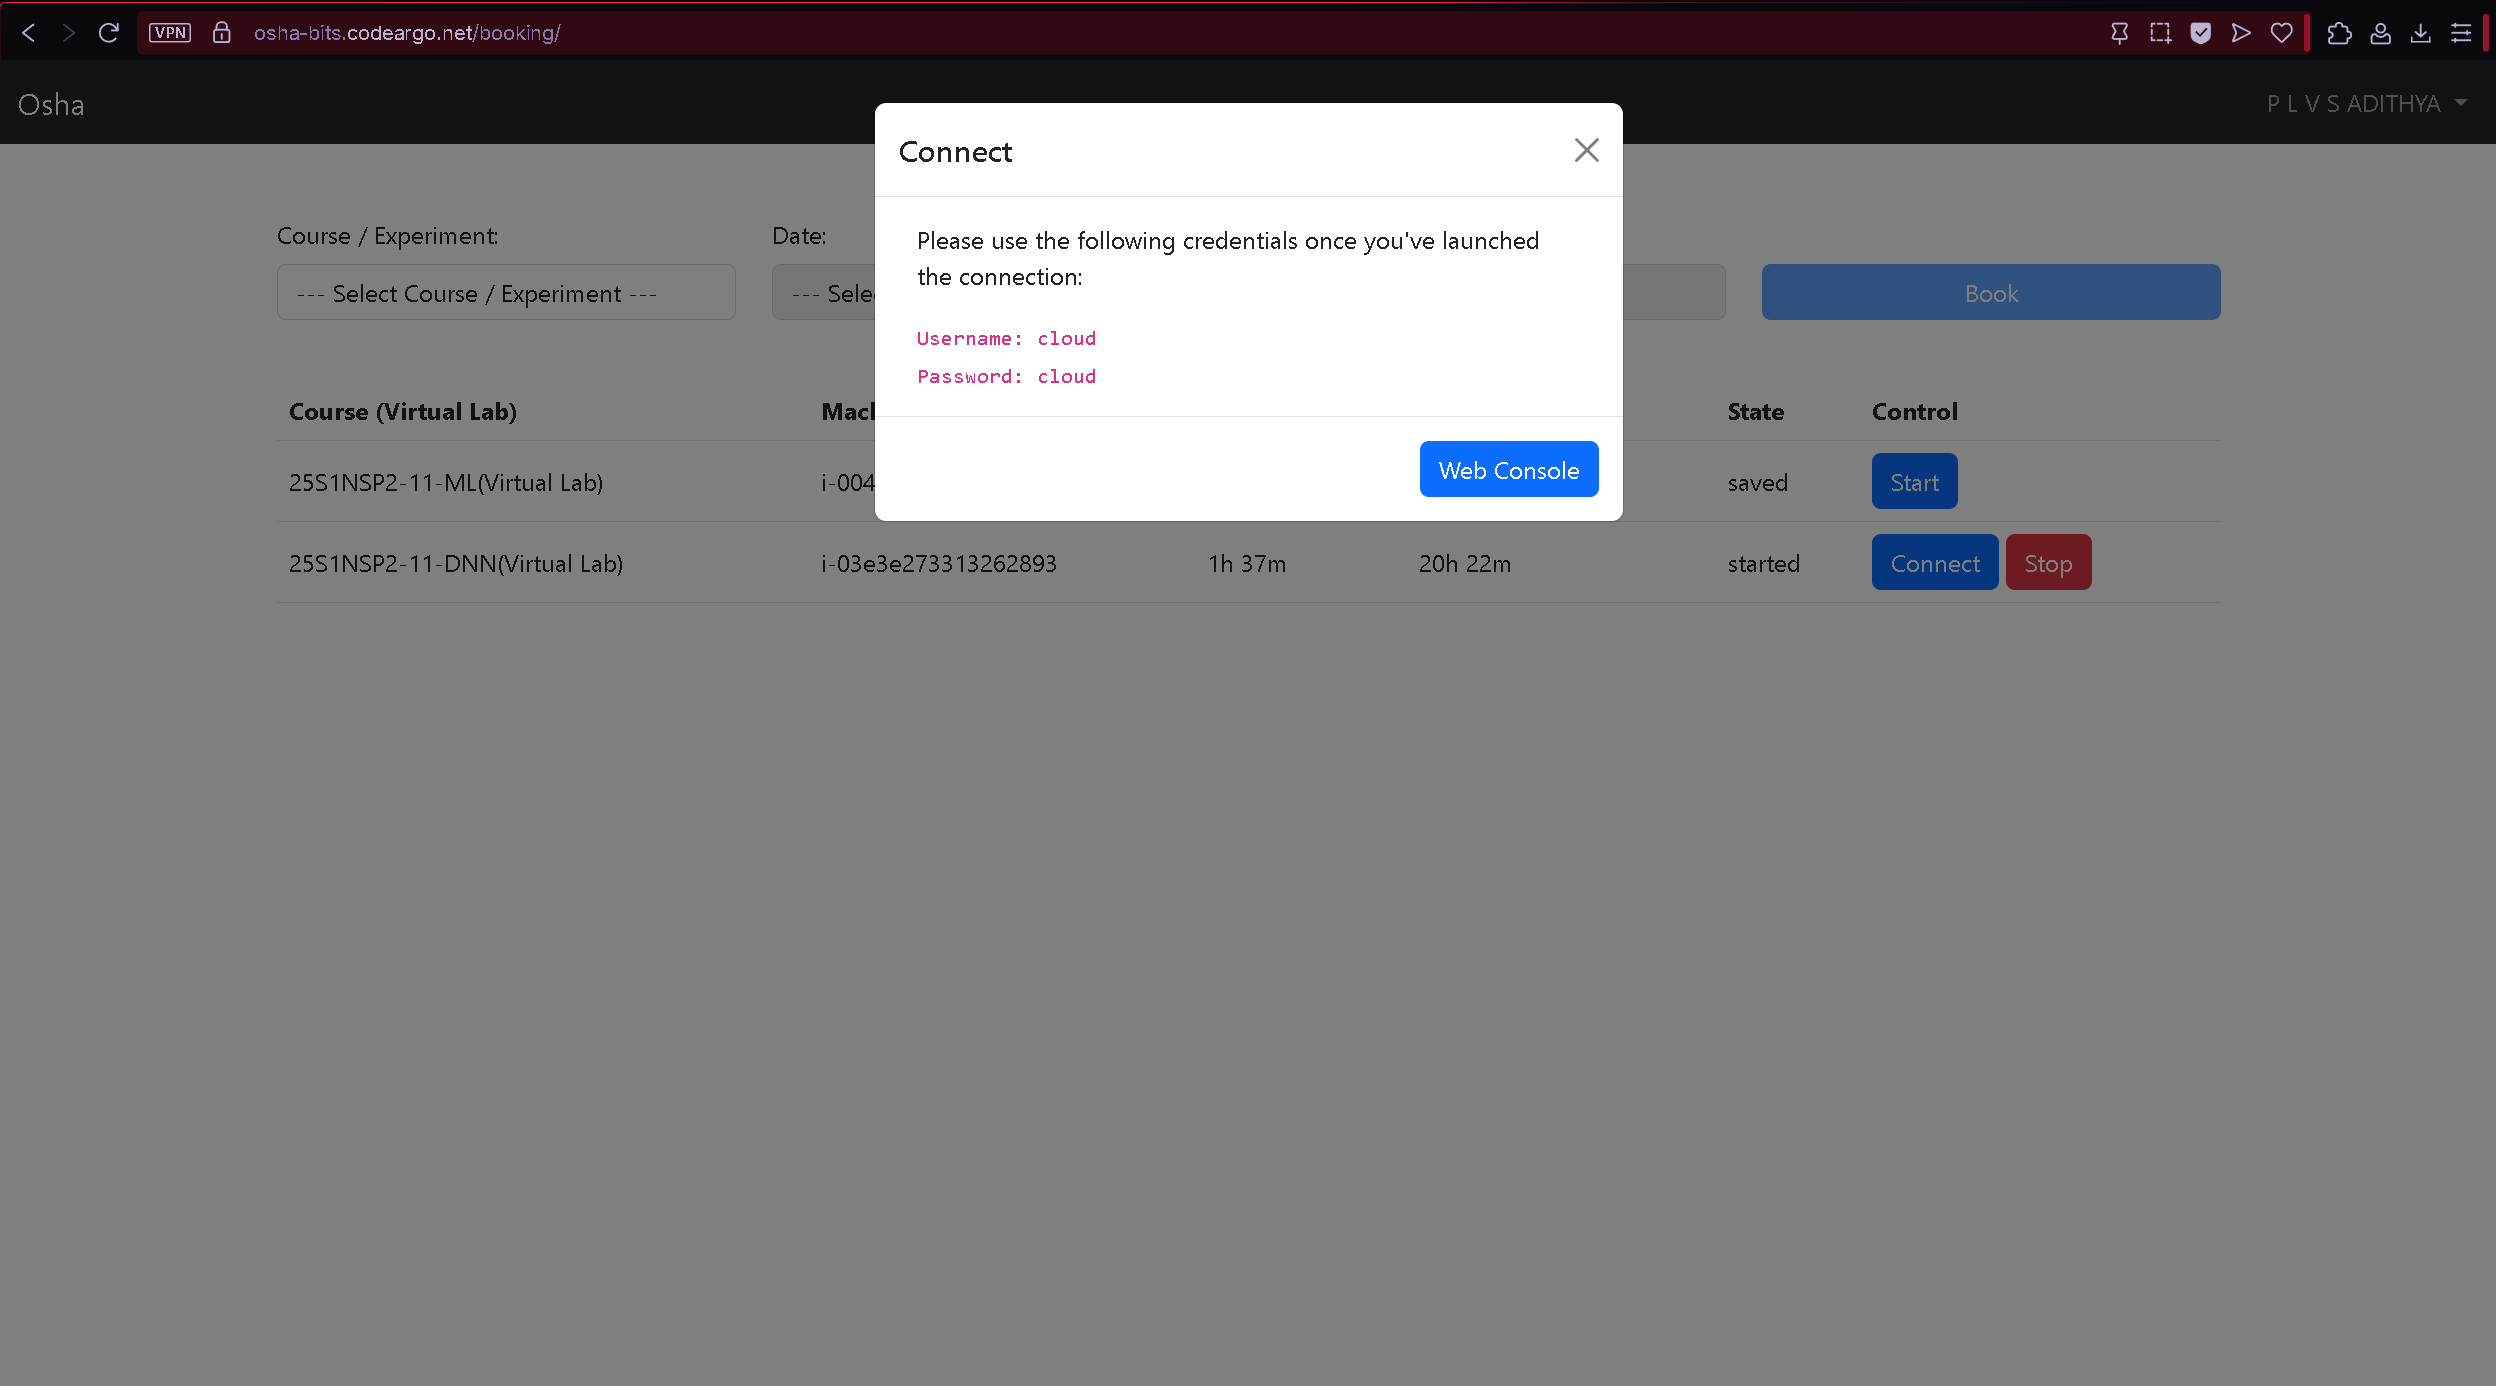
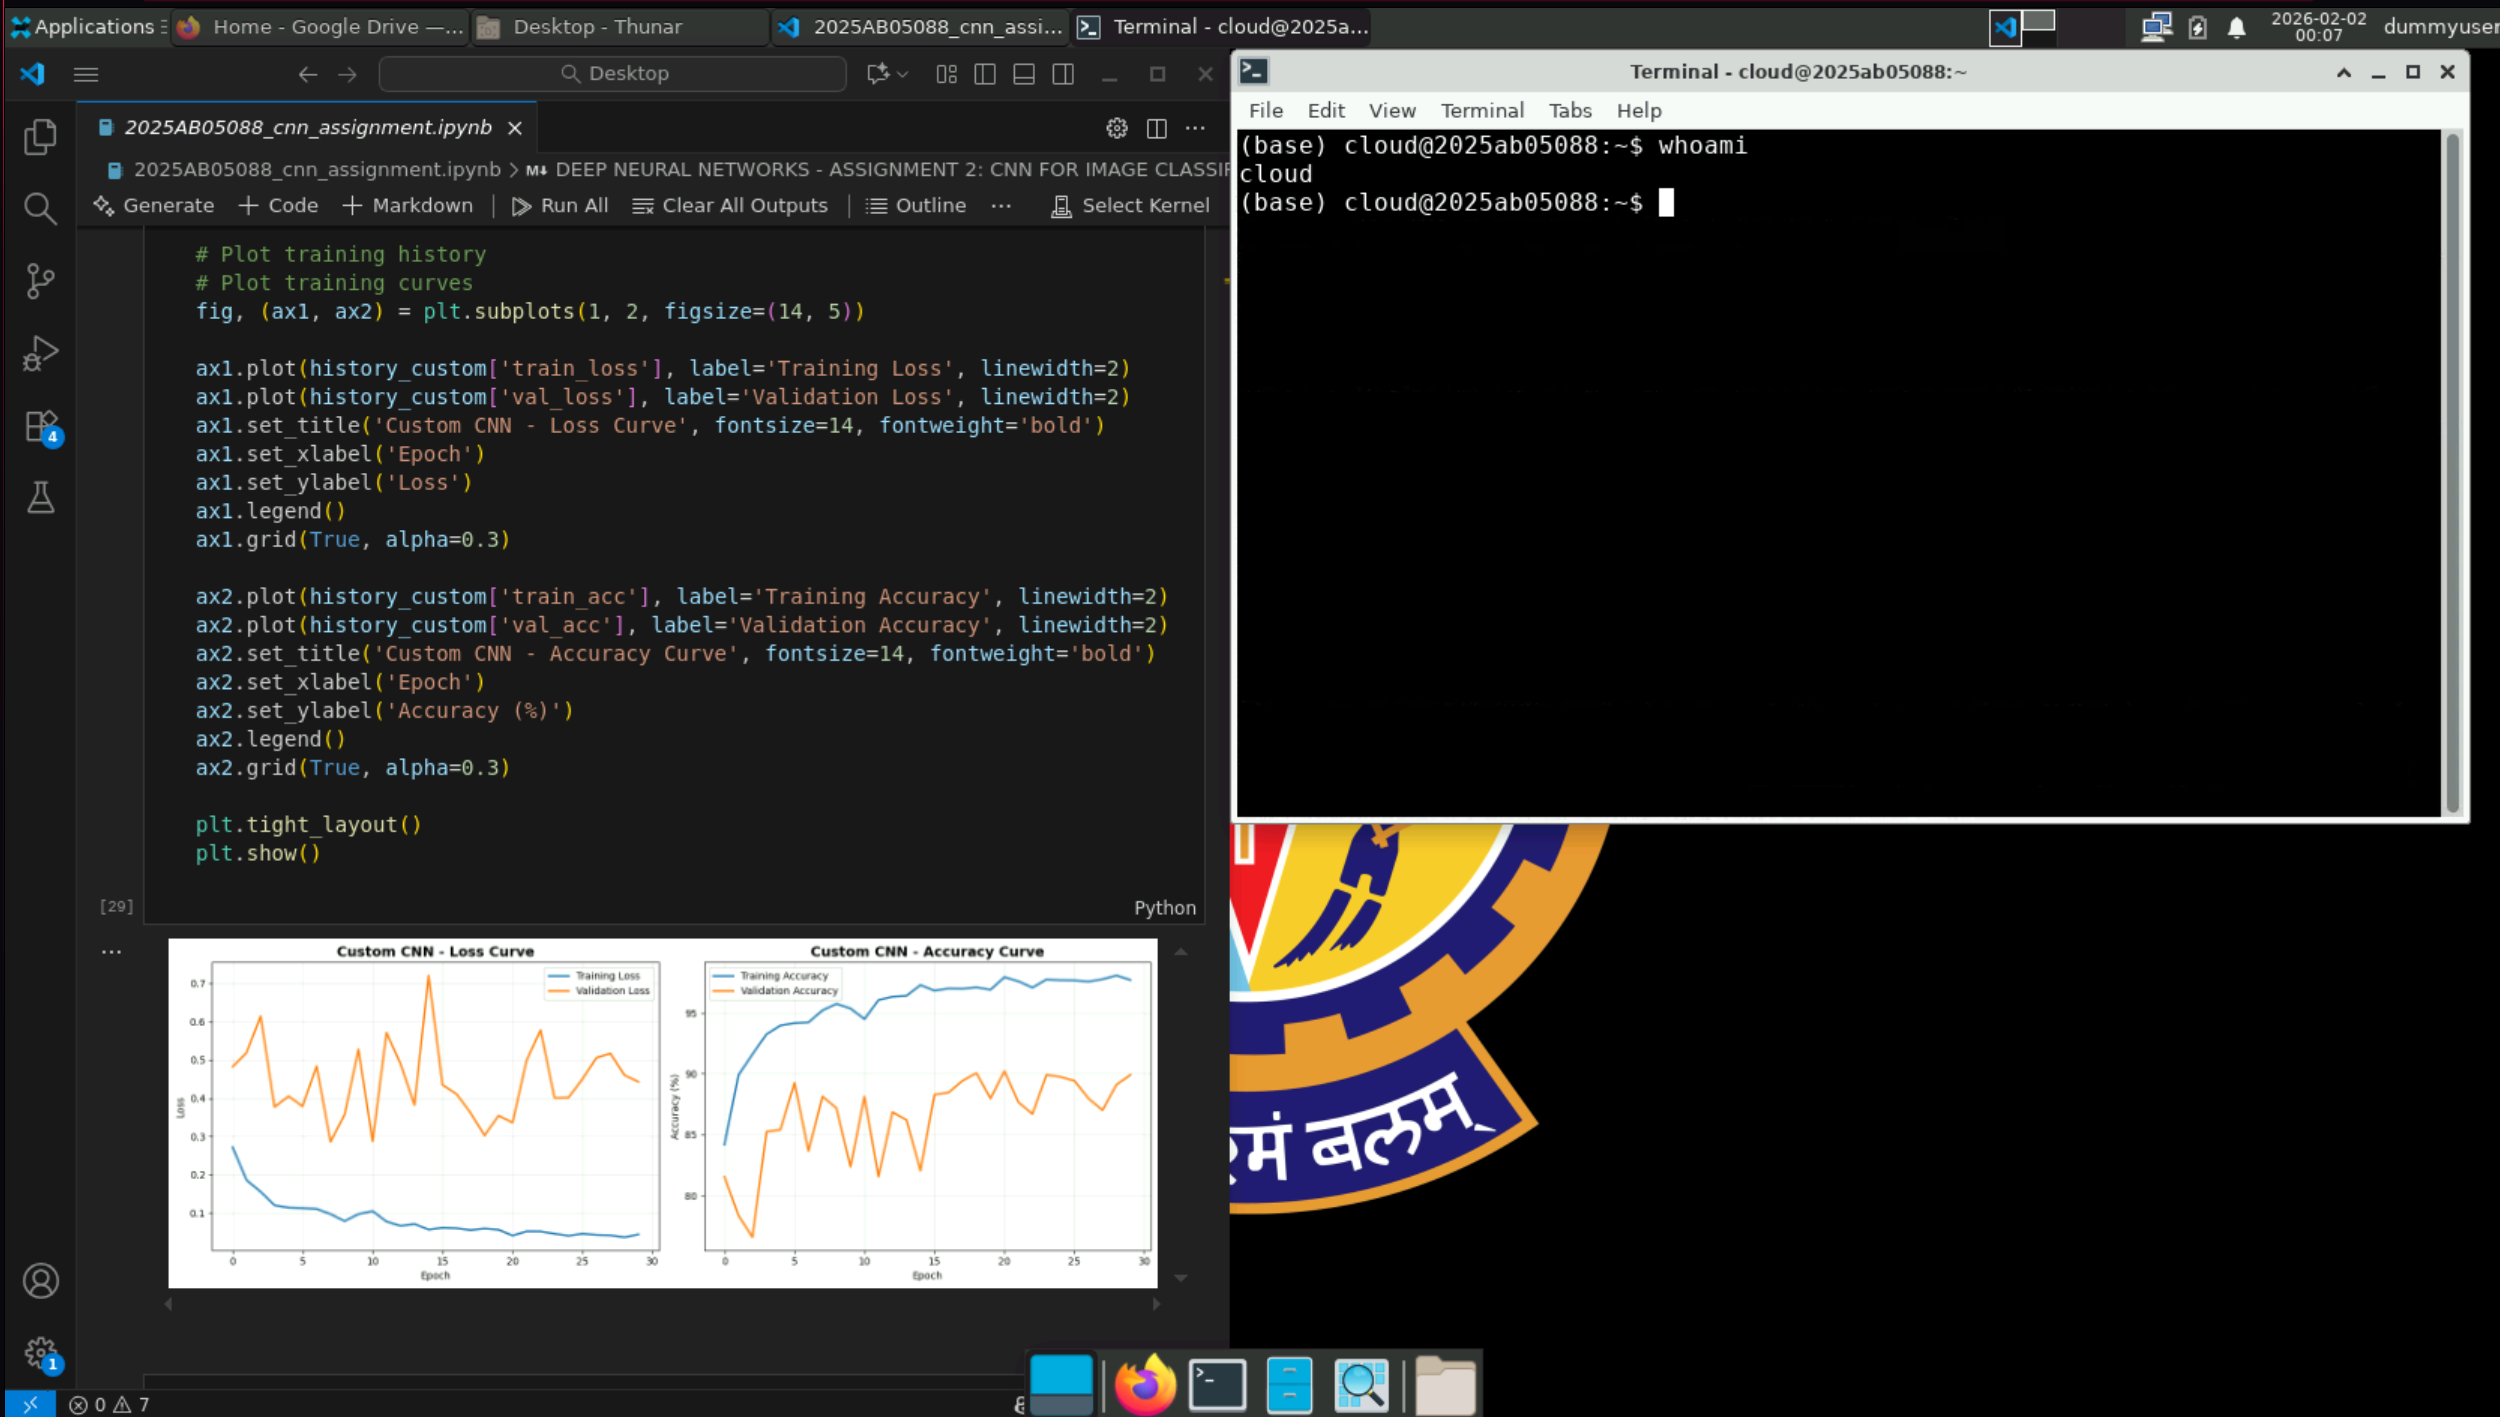